Lista 7 - IA

In [75]:
#questão 1
import numpy as np
import pandas as pd
from sklearn.datasets import load_wine

wine = load_wine()
features = wine.feature_names

X = wine.data
Y = wine.target

df = pd.DataFrame(X, columns=features)
display(df.head(5))
display(df.describe())
df.info()

#O dataset não precisa de limpeza, todos os dados são numéricos.




,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
dtypes: fl

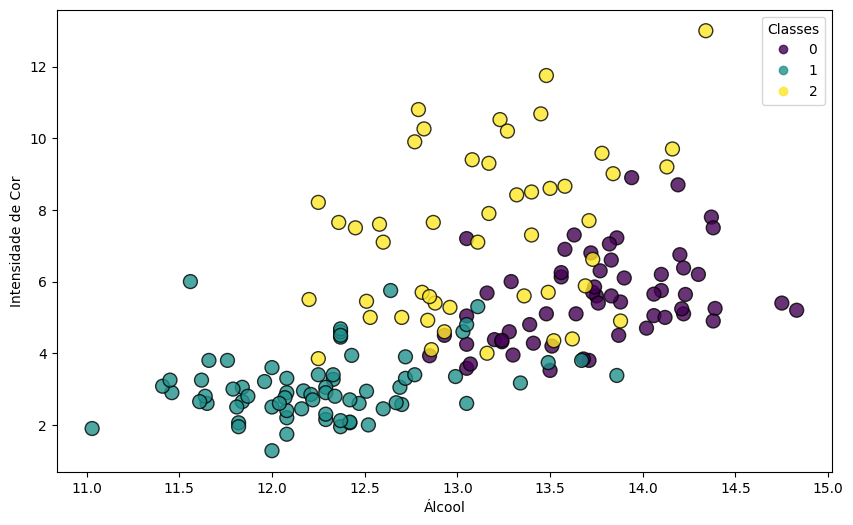

In [76]:
#Questão 2

#irei escolher teor alcoólico e intensidade da cor como exemplo 

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
scatter = plt.scatter(df['alcohol'], df['color_intensity'], c=Y, cmap='viridis', edgecolor='k', s=100, alpha=0.8)
plt.legend(*scatter.legend_elements(), title="Classes")
plt.xlabel('Álcool')
plt.ylabel('Intensidade de Cor')
plt.show()

#Não parecem separados visualmente

In [77]:
#Questão 3

from sklearn.cluster import KMeans
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X_normalizado = pd.DataFrame(scaler.fit_transform(X), columns=df.columns)
display(X_normalizado.head(5))

km = KMeans(n_clusters=3, random_state=42)

predict = km.fit_predict(X_normalizado)

display(predict)
print('\n')

print(f'Inércia: {km.inertia_}')
print('\n')

print(f'Clusters: {km.cluster_centers_}')



,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,0.897338,-0.104730,0.201439,-0.906977,1.526316,0.420804,0.553892,-0.358209,1.050000,0.318792,0.222222,0.924949,0.808050
1,0.114068,-0.057432,-0.633094,-1.930233,0.105263,0.278960,0.374251,-0.477612,-0.392857,-0.104027,0.251852,0.503043,0.777090
2,0.083650,0.334459,0.892086,-0.209302,0.157895,0.420804,0.661677,-0.238806,1.792857,0.332215,0.192593,0.316430,1.055728
3,1.003802,0.057432,0.402878,-0.627907,0.789474,1.413712,0.811377,-0.597015,0.892857,1.043624,-0.311111,0.543611,1.664603
4,0.144487,0.489865,1.467626,0.348837,1.052632,0.420804,0.332335,0.298507,0.378571,-0.124161,0.222222,0.121704,0.126935


array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 2, 0, 0, 0, 2, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1], dtype=int32)



Inércia: 676.8168459745548


Clusters: [[-0.6081236   0.03919991 -0.33573141  0.16242156 -0.36173768 -0.09028481
  -0.04167855  0.12698413  0.0531746  -0.57776712  0.27941211  0.02189381
  -0.35177814]
 [ 0.06396779  0.97449656  0.16589082  0.40492476  0.03508772 -0.63458953
  -0.78812962  0.66842259 -0.58445378  0.85392814 -0.80900508 -0.87897228
  -0.11236569]
 [ 0.44320342  0.07062922  0.25044964 -0.48582849  0.58305921  0.43705674
   0.49298278 -0.29477612  0.55602679  0.23180579  0.30740741  0.29906187
   0.85713364]]


K: 2 , Inércia: 854.67, Silhouette Score: 0.24772420578762383
K: 3 , Inércia: 676.82, Silhouette Score: 0.26446733931202676
K: 4 , Inércia: 623.00, Silhouette Score: 0.23608527992400177
K: 5 , Inércia: 581.17, Silhouette Score: 0.20007367677473464
K: 6 , Inércia: 547.69, Silhouette Score: 0.15037291028178668
K: 7 , Inércia: 517.29, Silhouette Score: 0.1547899171809561
K: 8 , Inércia: 491.18, Silhouette Score: 0.16035697144214872
K: 9 , Inércia: 485.32, Silhouette Score: 0.12572404914940852
K: 10 , Inércia: 473.77, Silhouette Score: 0.13664935764599254


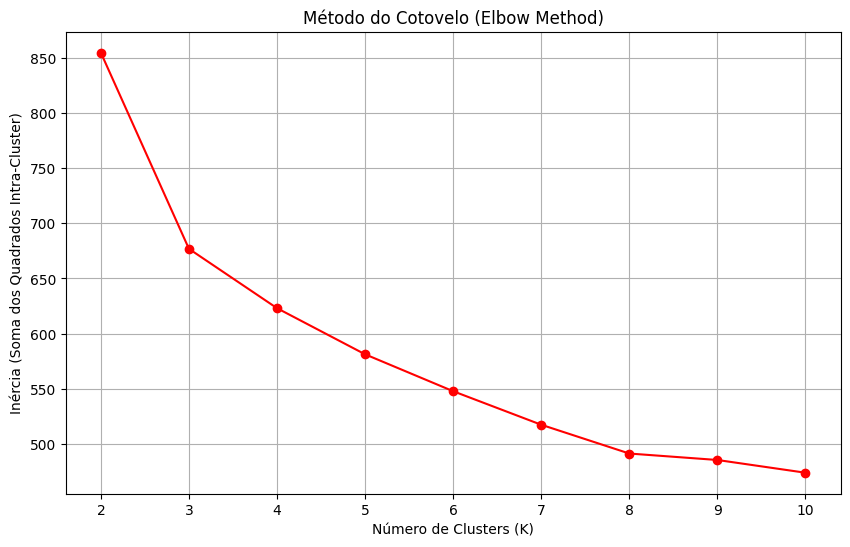

In [78]:
#Questão 4

from sklearn.metrics import silhouette_score

ks = range(2,11)
inercias = []
scores = []

for k in ks:

    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_normalizado)
    labels = kmeans.labels_
    inercia = kmeans.inertia_
    score = silhouette_score(X_normalizado, labels)

    inercias.append(inercia)
    scores.append(score)

    print(f'K: {k} , Inércia: {inercia:.2f}, Silhouette Score: {score}')

#Gráfico de Inercia
plt.figure(figsize=(10, 6))
plt.plot(ks, inercias, 'ro-')
plt.title('Método do Cotovelo (Elbow Method)')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inércia (Soma dos Quadrados Intra-Cluster)')
plt.xticks(ks)
plt.grid(True)


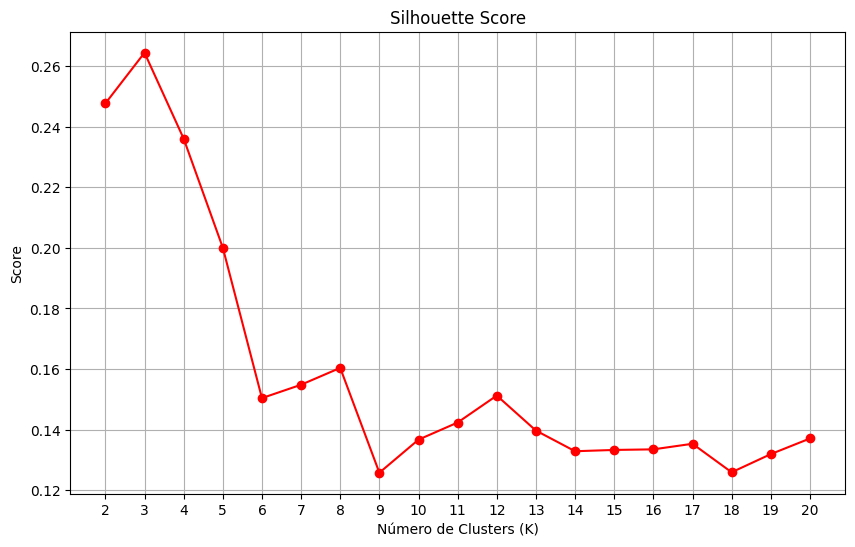

'O melhor k é o 3'

In [79]:
#Questão 5

from sklearn.metrics import silhouette_score

ks = range(2,21)

scores = []

for k in ks:

    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_normalizado)
    labels = kmeans.labels_
    score = silhouette_score(X_normalizado, labels)
    scores.append(score)

    #print(f'Score: {score}')

#Gráfico de scores
plt.figure(figsize=(10, 6))
plt.plot(ks, scores, 'ro-')
plt.title('Silhouette Score')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Score')
plt.xticks(ks)
plt.grid(True)
plt.show()

'''O melhor k é o 3'''

In [ ]:
#Questão 6

km = KMeans(n_clusters=3, random_state=42)
km.fit(X)

print(f'Inércia: {km.inertia_}')
print('\n')

print(f'Clusters: {km.cluster_centers_}')

'''Os clusters mudam. Como eu já havia começado a lista com os dados normalizados, resolvi
colocar aqui o kmeans com dados brutos para poder fazer a comparação'''

Inércia: 2633555.3324093386


Clusters: [[1.25985294e+01 2.45343137e+00 2.32186275e+00 2.06460784e+01
  9.36960784e+01 2.05362745e+00 1.64754902e+00 3.95980392e-01
  1.42509804e+00 4.67333332e+00 9.17843137e-01 2.39480392e+00
  5.21558824e+02]
 [1.33691837e+01 2.40000000e+00 2.39265306e+00 1.85142857e+01
  1.09081633e+02 2.44163265e+00 2.21367347e+00 3.25510204e-01
  1.70673469e+00 5.18836735e+00 9.59714286e-01 2.84795918e+00
  9.06346939e+02]
 [1.38507407e+01 1.77851852e+00 2.48777778e+00 1.69259259e+01
  1.05629630e+02 2.94148148e+00 3.13666667e+00 2.98888889e-01
  2.00703704e+00 6.27518519e+00 1.10296296e+00 3.00222222e+00
  1.30877778e+03]]


'Os clusters mudam. Como eu já havia começado a lista com os dados normalizados, resolvi\ncolocar aqui o kmeans com dados brutos para poder fazer a comparação'

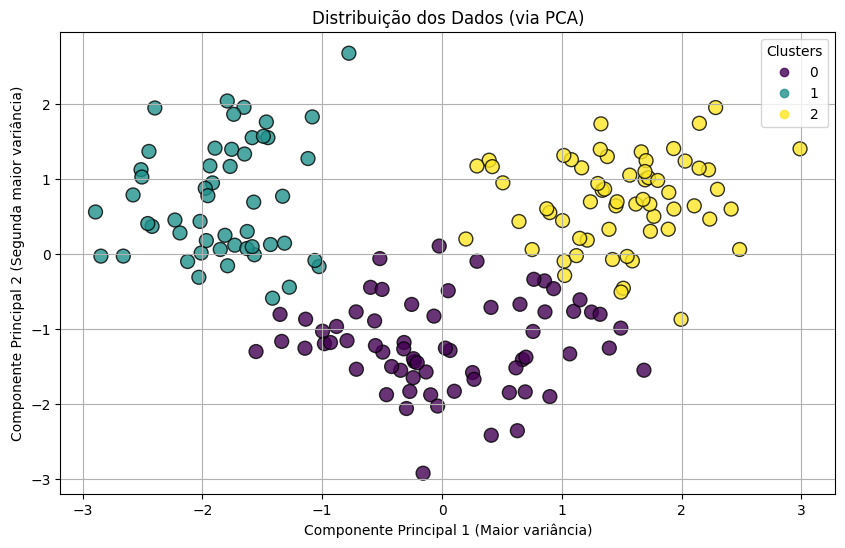

In [ ]:
#Questão 7

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_normalizado)

km = km = KMeans(n_clusters=3, random_state=42)
km.fit(X_pca)
labels = km.labels_

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', edgecolor='k', s=100, alpha=0.8)
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.title('Distribuição dos Dados (via PCA)')
plt.xlabel('Componente Principal 1 (Maior variância)')
plt.ylabel('Componente Principal 2 (Segunda maior variância)')
plt.grid(True)
plt.show()

'''Os dados ficam BEM MAIS separados'''


In [ ]:
#Questão 8

pca.explained_variance_ratio_

print(f'Porcentagem de informação utilizada: {sum(pca.explained_variance_ratio_)}')

'''Apenas metade foi preservado. Conseguimos plotar bem o gráfico, mas houve muita perda'''

Porcentagem de informação utilizada: 0.5253443688085926


In [ ]:
#Questão 9

km = km = KMeans(n_clusters=3, random_state=42)
km.fit(X_pca)
km.inertia_

'''A inércia saiu de entorno de 600 para 150, o que é ótimo!'''

142.77912404523033

In [ ]:
#Questão 10

'''
Usamos pca para datasets com muitas dimensões, para poder evitar problemas com a dimensionalidade, 
principalmente nos algoritmos que usam distancia euclidiana

Obtemos maior visualização dos dados, menor inércia e melhor perfomance do modelo

Isso pode prejudicar o modelo pois pode perder muita informação, como aconteceu nessa aplicação
'''